# Exploration des données climatiques – France
Projet ETL M1 Data & IA – Ynov 2025-2026

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = '../database/climat_france.db'
conn = sqlite3.connect(DB_PATH)
sns.set_theme(style='whitegrid')

## 1. Aperçu des données

In [2]:
df_villes = pd.read_sql('SELECT * FROM villes', conn)
print(df_villes)

df = pd.read_sql('SELECT * FROM mesures_horaires LIMIT 5', conn)
df.head()

   id        nom  latitude  longitude  elevation      timezone
0   1      Paris     48.86       2.34       43.0  Europe/Paris
1   2  Marseille     43.30       5.38       30.0  Europe/Paris
2   3       Lyon     45.74       4.84      176.0  Europe/Paris
3   4       Nice     43.70       7.26       17.0  Europe/Paris
4   5   Toulouse     43.60       1.44      149.0  Europe/Paris


,id,ville_id,datetime,temperature_2m,humidite_relative,precipitations,pression_surface,temperature_ressentie,proba_precipitations,saison,tranche_horaire,confort_thermique,pluie
0,1,3,2024-01-01 00:00:00,4.9,87.0,0.0,993.8,2.8,0.0,Hiver,Nuit,Froid,0
1,2,3,2024-01-01 01:00:00,5.0,79.0,0.0,994.6,2.4,0.0,Hiver,Nuit,Froid,0
2,3,3,2024-01-01 02:00:00,4.5,83.0,0.0,994.7,1.8,0.0,Hiver,Nuit,Froid,0
3,4,3,2024-01-01 03:00:00,4.5,83.0,0.0,995.2,2.0,0.0,Hiver,Nuit,Froid,0
4,5,3,2024-01-01 04:00:00,4.5,84.0,0.0,995.7,2.1,0.0,Hiver,Nuit,Froid,0


In [3]:
# Volume de données par ville
q = '''
SELECT v.nom, COUNT(*) AS nb_mesures,
       MIN(m.datetime) AS premiere_mesure,
       MAX(m.datetime) AS derniere_mesure
FROM mesures_horaires m
JOIN villes v ON v.id = m.ville_id
GROUP BY v.nom
'''
pd.read_sql(q, conn)

,nom,nb_mesures,premiere_mesure,derniere_mesure
0,Lyon,17544,2024-01-01 00:00:00,2025-12-31 23:00:00
1,Marseille,17544,2024-01-01 00:00:00,2025-12-31 23:00:00
2,Nice,17544,2024-01-01 00:00:00,2025-12-31 23:00:00
3,Paris,17544,2024-01-01 00:00:00,2025-12-31 23:00:00
4,Toulouse,17544,2024-01-01 00:00:00,2025-12-31 23:00:00


## 2. Température moyenne par ville et par mois

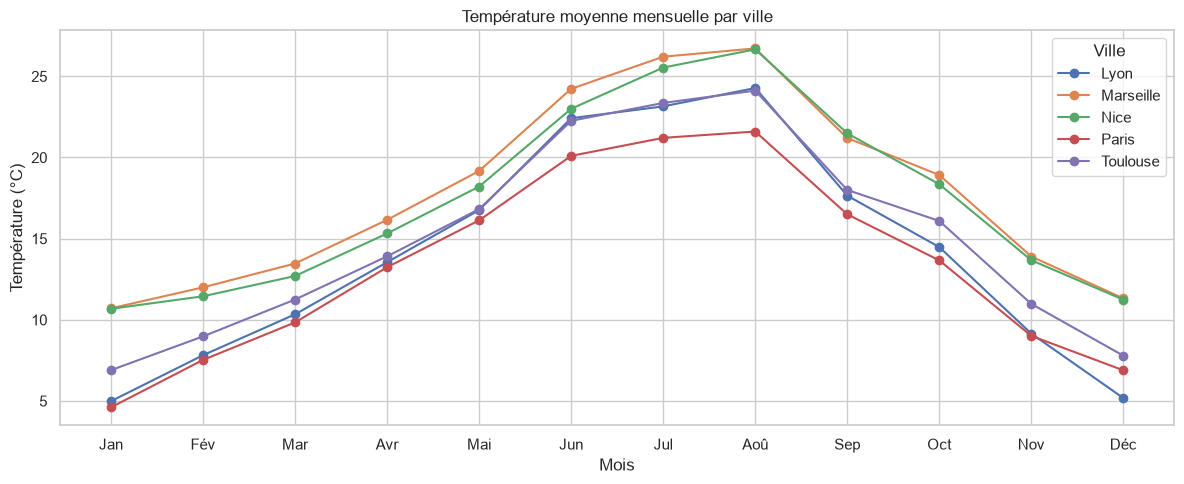

In [4]:
q = '''
SELECT v.nom AS ville, a.mois, ROUND(AVG(a.temp_moy), 2) AS temp_moy
FROM agregats_journaliers a
JOIN villes v ON v.id = a.ville_id
GROUP BY v.nom, a.mois
ORDER BY v.nom, a.mois
'''
df_temp = pd.read_sql(q, conn)
pivot = df_temp.pivot(index='mois', columns='ville', values='temp_moy')

pivot.plot(figsize=(12, 5), marker='o')
plt.title('Température moyenne mensuelle par ville')
plt.xlabel('Mois')
plt.ylabel('Température (°C)')
plt.xticks(range(1, 13), ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc'])
plt.legend(title='Ville')
plt.tight_layout()
plt.show()

## 3. Précipitations totales par ville et par mois

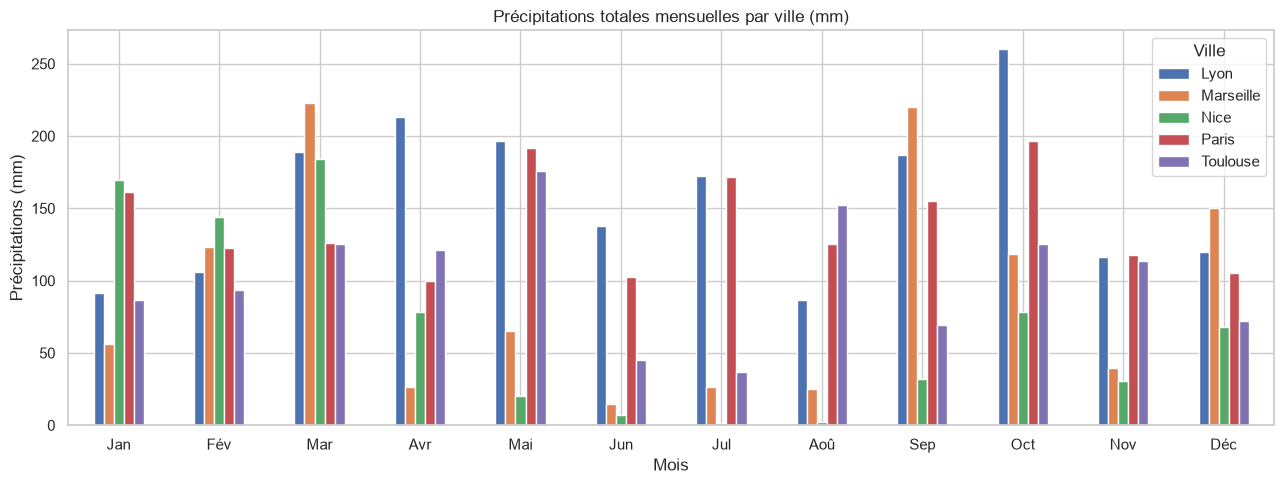

In [5]:
q = '''
SELECT v.nom AS ville, a.mois, ROUND(SUM(a.precipitations_totales), 1) AS pluie_mm
FROM agregats_journaliers a
JOIN villes v ON v.id = a.ville_id
GROUP BY v.nom, a.mois
ORDER BY v.nom, a.mois
'''
df_pluie = pd.read_sql(q, conn)
pivot_p = df_pluie.pivot(index='mois', columns='ville', values='pluie_mm')

pivot_p.plot(kind='bar', figsize=(13, 5))
plt.title('Précipitations totales mensuelles par ville (mm)')
plt.xlabel('Mois')
plt.ylabel('Précipitations (mm)')
plt.xticks(range(12), ['Jan','Fév','Mar','Avr','Mai','Jun','Jul','Aoû','Sep','Oct','Nov','Déc'], rotation=0)
plt.legend(title='Ville')
plt.tight_layout()
plt.show()

## 4. Distribution des températures par saison

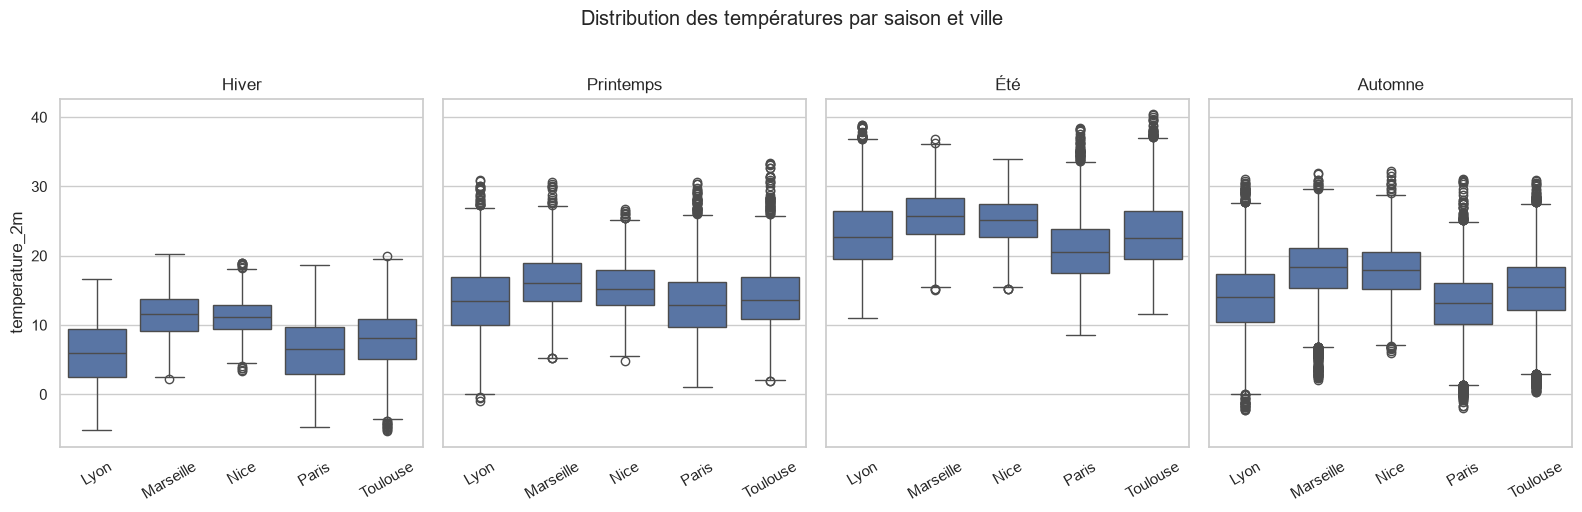

In [6]:
q = '''
SELECT v.nom AS ville, m.saison, m.temperature_2m
FROM mesures_horaires m
JOIN villes v ON v.id = m.ville_id
WHERE m.saison IS NOT NULL
'''
df_saison = pd.read_sql(q, conn)
ordre_saisons = ['Hiver', 'Printemps', 'Été', 'Automne']

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
for ax, saison in zip(axes, ordre_saisons):
    data = df_saison[df_saison['saison'] == saison]
    sns.boxplot(data=data, x='ville', y='temperature_2m', ax=ax)
    ax.set_title(saison)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Distribution des températures par saison et ville', y=1.02)
plt.tight_layout()
plt.show()

## 5. Heatmap – température horaire moyenne (Paris)

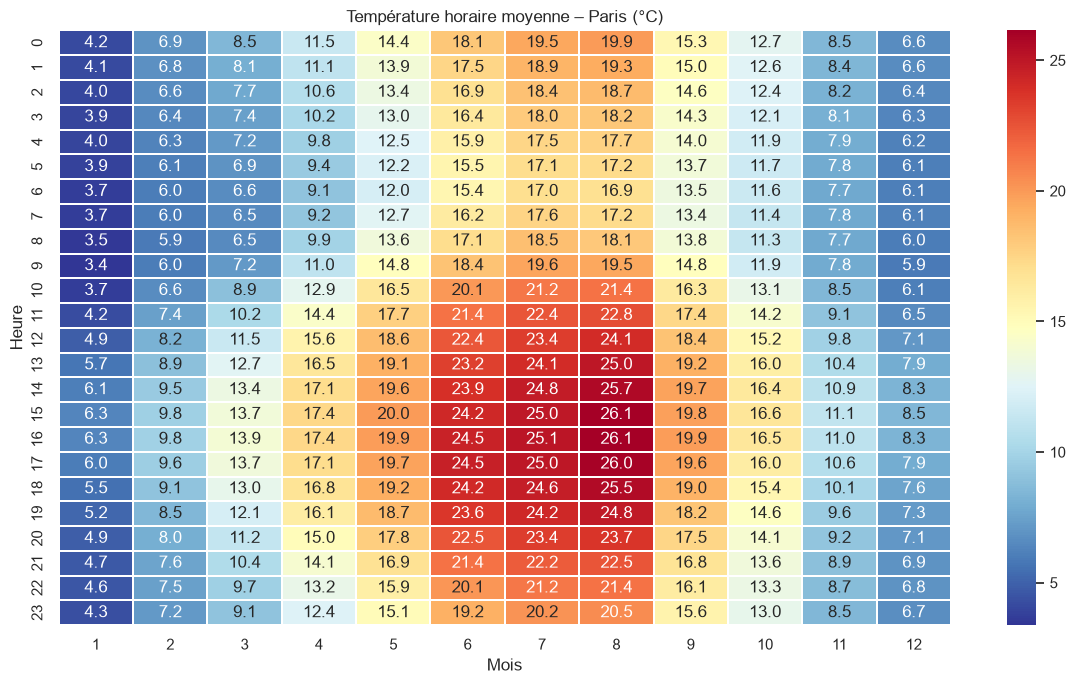

In [10]:
q = '''
SELECT CAST(strftime('%m', m.datetime) AS INTEGER) AS mois,
       CAST(strftime('%H', m.datetime) AS INTEGER) AS heure,
       ROUND(AVG(m.temperature_2m), 2) AS temp_moy
FROM mesures_horaires m
JOIN villes v ON v.id = m.ville_id
WHERE v.nom = 'Paris'
GROUP BY mois, heure
ORDER BY mois, heure
'''
df_heat = pd.read_sql(q, conn)
pivot_h = df_heat.pivot(index='heure', columns='mois', values='temp_moy')

plt.figure(figsize=(12, 7))
sns.heatmap(pivot_h, cmap='RdYlBu_r', annot=True, fmt='.1f', linewidths=0.3)
plt.title('Température horaire moyenne – Paris (°C)')
plt.xlabel('Mois')
plt.ylabel('Heure')
plt.tight_layout()
plt.show()

In [ ]:
conn.close()